<a href="https://colab.research.google.com/github/Taniya1701/CSL701-CS06_Machine-Learning-Lab/blob/main/Experiments%20and%20Mini-Project/ML_Experiment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name : Taniya Anil Bhise      Roll No: CS06       Batch: CS01

Aim

To implement Support Vector Machine (SVM) for classification of the Iris dataset and visualize its decision boundary and compare it with a normal linear classification boundary.

## Objectives

1. To understand the concept of Support Vector Machine.
2. To implement SVM using Python.
3. To visualize the SVM decision boundary.
4. To identify the support vectors.
5. To compare the SVM boundary with a normal linear classification boundary.
6. To evaluate the performance of the classifiers.

# Relevant Theory

### Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification.

SVM finds a decision boundary that separates different classes while trying to maximize the distance, called the **margin**, between the classes.

The points closest to the decision boundary are called **support vectors**.

For a linear SVM, the decision boundary can be represented as:

$$
w^T x + b = 0
$$

where:

- $w$ = weight vector
- $x$ = input features
- $b$ = bias


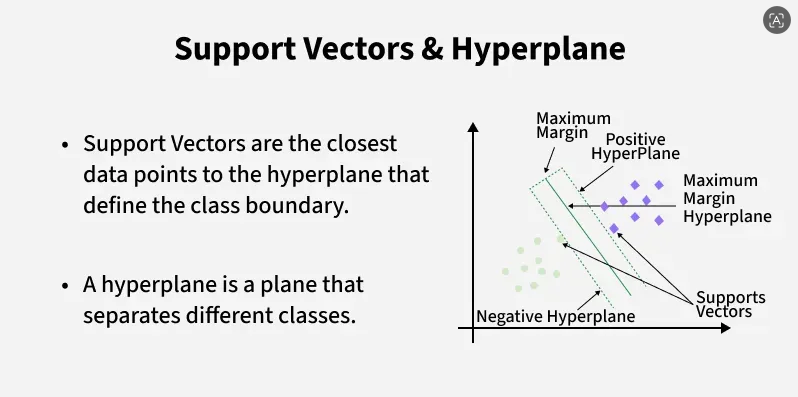
### Kernel

SVM can use different kernels to create decision boundaries.

Common kernels are:

- Linear
- Polynomial
- RBF
- Sigmoid

In this experiment, we mainly use the **Linear SVM** and **RBF SVM**.

---

# Dataset Information

Get the IRIS dataset from Kaggle using below link

https://www.kaggle.com/datasets/uciml/iris

The Iris dataset contains measurements of Iris flowers belonging to three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The four features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

For visualization, we will use:

**Petal Length and Petal Width.**

# Task 1: Import Libraries and Load Dataset

Load the Iris dataset.

---

In [2]:
# Task 1: Import Libraries and Load Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Iris dataset
df = pd.read_csv("Iris.csv")

print("Dataset loaded successfully!")
display(df.head())

Dataset loaded successfully!


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


# Task 2: Explore the Dataset

In [3]:
# Task 2: Explore the Dataset

print("First 5 records:")
display(df.head())

print("\nDataset Shape:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
display(df.describe())

print("\nTarget Class Distribution:")
print(df["Species"].value_counts())

First 5 records:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa



Dataset Shape:
Rows: 150
Columns: 6

Column Names:
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

Data Types:
Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

Missing Values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Statistical Summary:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000



Target Class Distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


# Task 3: Select Features and Target

Remove the `Id` column.

Select Remaining Features

In [4]:
# Task 3: Select Features and Target

# Remove Id column
df = df.drop("Id", axis=1)

# Select features
X = df.drop("Species", axis=1)

# Select target
y = df["Species"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("Species")

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

print("\nFirst 5 feature records:")
display(X.head())

print("\nFirst 5 target records:")
display(y.head())

Features:
['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

Target:
Species

Shape of X: (150, 4)
Shape of y: (150,)

First 5 feature records:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



First 5 target records:


,Species
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa


# Task 4: Split and Scale the Data

Divide the dataset into training and testing sets.

In [5]:
# Task 4: Split and Scale the Data

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create StandardScaler
scaler = StandardScaler()

# Fit scaler on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nScaled training data:")
display(pd.DataFrame(X_train_scaled, columns=X.columns).head())

Training data shape: (120, 4)
Testing data shape: (30, 4)

Scaled training data:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,-1.721568,-0.324840,-1.347036,-1.320168
1,-1.124492,-1.226129,0.414290,0.651867
2,1.144395,-0.550162,0.584741,0.257460
3,-1.124492,0.125805,-1.290219,-1.451638
4,-0.408002,-1.226129,0.130206,0.125991


# Task 5: Implement Linear SVM

Create an SVM model using a **linear kernel**.

Make predictions.

In [6]:
# Task 5: Implement Linear SVM

# Create Linear SVM model
svm_model = SVC(kernel="linear", random_state=42)

# Train the model
svm_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test_scaled)

print("Linear SVM model trained successfully!")

print("\nPredictions:")
print(y_pred_svm)

Linear SVM model trained successfully!

Predictions:
['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa'
 'Iris-virginica' 'Iris-setosa']


# Task 6: Evaluate SVM

### Calculate Accuracy

Calculate the accuracy of the SVM model.

### Confusion Matrix

Generate the confusion matrix to evaluate the classification results.

### Classification Report

Generate the classification report containing:

- Precision
- Recall
- F1-Score
- Support

---


In [7]:
# Task 6: Evaluate SVM

# Calculate accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("Linear SVM Accuracy:")
print(svm_accuracy)

print("\nLinear SVM Accuracy (%):")
print(svm_accuracy * 100)

# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

print("\nConfusion Matrix:")
print(cm_svm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

Linear SVM Accuracy:
1.0

Linear SVM Accuracy (%):
100.0

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



# Task 7: Visualize SVM Decision Boundary

For visualization, we use only two features:

- Petal Length
- Petal Width

### Create the 2-D Dataset

Select **Petal Length** and **Petal Width** as the input features.

### Split the Data

Divide the 2-D dataset into training and testing sets.

### Scale the Data

Standardize the selected features before training the SVM model.

### Train SVM

Train an SVM classifier using a **linear kernel**.

### Plot Decision Boundary

Visualize the SVM decision boundary along with the data points.

---

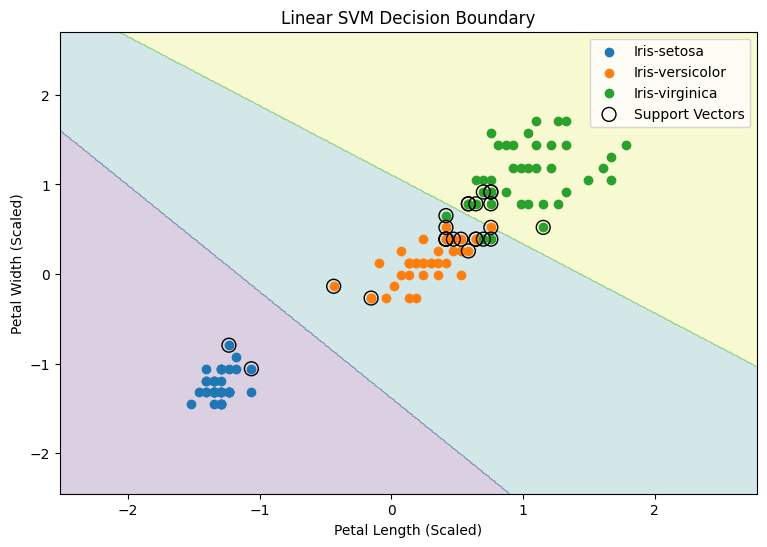

Number of Support Vectors: 25


In [9]:
# Plot SVM Decision Boundary

plt.figure(figsize=(9, 6))

# Create mesh grid
x_min = X_train_2d_scaled[:, 0].min() - 1
x_max = X_train_2d_scaled[:, 0].max() + 1

y_min = X_train_2d_scaled[:, 1].min() - 1
y_max = X_train_2d_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Predict each point in the mesh
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Convert classes into numbers for plotting
class_mapping = {
    "Iris-setosa": 0,
    "Iris-versicolor": 1,
    "Iris-virginica": 2
}

Z_numeric = np.vectorize(class_mapping.get)(Z)

# Plot regions
plt.contourf(xx, yy, Z_numeric, alpha=0.2)

# Plot data points
for species, number in class_mapping.items():
    mask = y_train_2d == species
    plt.scatter(
        X_train_2d_scaled[mask, 0],
        X_train_2d_scaled[mask, 1],
        label=species
    )

# Plot support vectors
plt.scatter(
    svm_2d.support_vectors_[:, 0],
    svm_2d.support_vectors_[:, 1],
    s=100,
    facecolors="none",
    edgecolors="black",
    label="Support Vectors"
)

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("Linear SVM Decision Boundary")
plt.legend()
plt.show()

print("Number of Support Vectors:", len(svm_2d.support_vectors_))

# Task 8: Normal Linear Classification Boundary

For comparison, we use **Logistic Regression** as a normal linear classifier.

Train a Logistic Regression model using the same two features and visualize its decision boundary.

---

Logistic Regression Accuracy:
0.9333333333333333

Logistic Regression Accuracy (%):
93.33333333333333




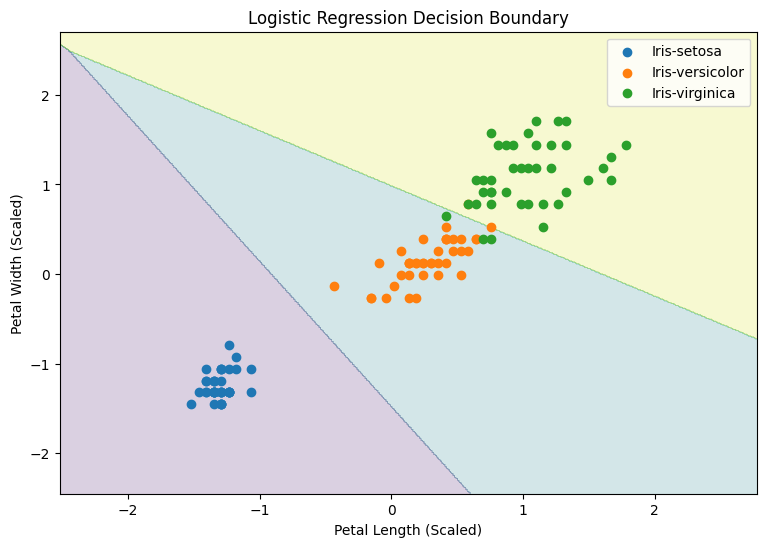

In [19]:
# Task 8: Logistic Regression

# Create Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=200,
    random_state=42
)

# Train the model
logistic_model.fit(X_train_2d_scaled, y_train_2d)

# Make predictions
y_pred_logistic = logistic_model.predict(X_test_2d_scaled)

# Calculate accuracy
logistic_accuracy = accuracy_score(y_test_2d, y_pred_logistic)

print("Logistic Regression Accuracy:")
print(logistic_accuracy)

print("\nLogistic Regression Accuracy (%):")
print(logistic_accuracy * 100)

# Plot Logistic Regression Decision Boundary
print("\n")

plt.figure(figsize=(9, 6))

# Create mesh grid
xx, yy = np.meshgrid(
    np.linspace(
        X_train_2d_scaled[:, 0].min() - 1,
        X_train_2d_scaled[:, 0].max() + 1,
        500
    ),
    np.linspace(
        X_train_2d_scaled[:, 1].min() - 1,
        X_train_2d_scaled[:, 1].max() + 1,
        500
    )
)

# Predict mesh points
Z = logistic_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

Z_numeric = np.vectorize(class_mapping.get)(Z)

# Plot decision regions
plt.contourf(xx, yy, Z_numeric, alpha=0.2)

# Plot training points
for species, number in class_mapping.items():
    mask = y_train_2d == species
    plt.scatter(
        X_train_2d_scaled[mask, 0],
        X_train_2d_scaled[mask, 1],
        label=species
    )

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.show()

# Task 9: Compare SVM and Normal Boundary

Plot both the **SVM** and **Logistic Regression** decision boundaries on the same graph.

Compare how the two classifiers separate the different classes.

---

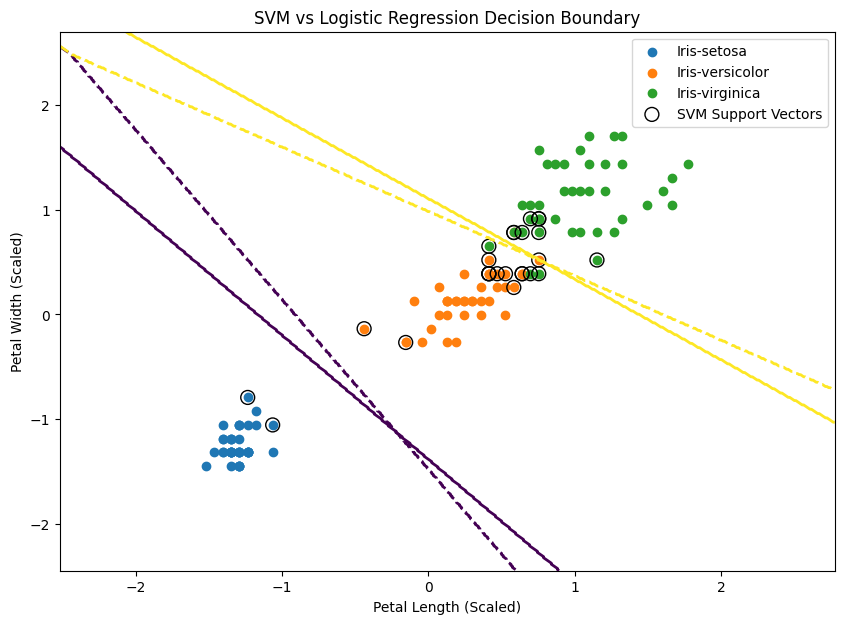

In [13]:
# Task 9: Compare SVM and Logistic Regression Boundaries

plt.figure(figsize=(10, 7))

# Create mesh grid
x_min = X_train_2d_scaled[:, 0].min() - 1
x_max = X_train_2d_scaled[:, 0].max() + 1

y_min = X_train_2d_scaled[:, 1].min() - 1
y_max = X_train_2d_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

grid = np.c_[xx.ravel(), yy.ravel()]

# SVM prediction
Z_svm = svm_2d.predict(grid)
Z_svm = np.vectorize(class_mapping.get)(Z_svm)
Z_svm = Z_svm.reshape(xx.shape)

# Logistic Regression prediction
Z_logistic = logistic_model.predict(grid)
Z_logistic = np.vectorize(class_mapping.get)(Z_logistic)
Z_logistic = Z_logistic.reshape(xx.shape)

# Plot SVM boundary
plt.contour(
    xx,
    yy,
    Z_svm,
    levels=[0.5, 1.5],
    linewidths=2
)

# Plot Logistic Regression boundary
plt.contour(
    xx,
    yy,
    Z_logistic,
    levels=[0.5, 1.5],
    linestyles="dashed",
    linewidths=2
)

# Plot data points
for species, number in class_mapping.items():
    mask = y_train_2d == species

    plt.scatter(
        X_train_2d_scaled[mask, 0],
        X_train_2d_scaled[mask, 1],
        label=species
    )

# Plot SVM support vectors
plt.scatter(
    svm_2d.support_vectors_[:, 0],
    svm_2d.support_vectors_[:, 1],
    s=100,
    facecolors="none",
    edgecolors="black",
    label="SVM Support Vectors"
)

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("SVM vs Logistic Regression Decision Boundary")
plt.legend()
plt.show()

# Task 10: Compare Performance

Compare the performance of the **Linear SVM** and **Logistic Regression** using:

- Accuracy
- Confusion Matrix
- Classification Report

---

In [20]:
# Task 10: Compare Performance

# SVM Accuracy
svm_accuracy_2d = accuracy_score(y_test_2d, svm_2d.predict(X_test_2d_scaled))

# Logistic Regression Accuracy
logistic_accuracy_2d = accuracy_score(
    y_test_2d,
    y_pred_logistic
)

print("========== PERFORMANCE COMPARISON ==========")

print("\nLinear SVM Accuracy:")
print(svm_accuracy_2d)

print("\nLogistic Regression Accuracy:")
print(logistic_accuracy_2d)

print("\nLinear SVM Accuracy (%):")
print(svm_accuracy_2d * 100)

print("\nLogistic Regression Accuracy (%):")
print(logistic_accuracy_2d * 100)

# Logistic Regression Confusion Matrix

print("\n\nLogistic Regression Confusion Matrix:")
print(confusion_matrix(y_test_2d, y_pred_logistic))

print("\nLogistic Regression Classification Report:")
print(
    classification_report(
        y_test_2d,
        y_pred_logistic
    )
)

# Final Performance Comparison

comparison = pd.DataFrame({
    "Classifier": [
        "Linear SVM",
        "Logistic Regression"
    ],
    "Accuracy": [
        svm_accuracy_2d,
        logistic_accuracy_2d
    ],
    "Accuracy (%)": [
        svm_accuracy_2d * 100,
        logistic_accuracy_2d * 100
    ]
})

display(comparison)

========== PERFORMANCE COMPARISON ==========

Linear SVM Accuracy:
0.9333333333333333

Logistic Regression Accuracy:
0.9333333333333333

Linear SVM Accuracy (%):
93.33333333333333

Logistic Regression Accuracy (%):
93.33333333333333


Logistic Regression Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Logistic Regression Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



,Classifier,Accuracy,Accuracy (%)
0,Linear SVM,0.933333,93.333333
1,Logistic Regression,0.933333,93.333333


# Conclusion

The experiment successfully demonstrated the implementation of **Support Vector Machine (SVM)** using the Iris dataset. The dataset was preprocessed and standardized before training the model.

A **Linear SVM** was implemented and its decision boundary was visualized along with the support vectors. A normal linear classification boundary using **Logistic Regression** was also visualized for comparison.